#Telling Apart 7 Kinds of Steel Surface Defects
### A machine-learning project: multi-class quality inspection on the UCI Steel Plates dataset


##Import

In [13]:
import urllib.request, zipfile, os, warnings
import numpy as np      #for numerical calculations
import pandas as pd     #for data handling
import matplotlib.pyplot as plt   #for visulising

from sklearn.linear_model import LogisticRegression #logistic regression model
from sklearn.ensemble import RandomForestClassifier #random forest model
from xgboost import XGBClassifier      #XGBoost model
from sklearn.model_selection import StratifiedKFold #cross-validation
from sklearn.preprocessing import StandardScaler    #for scaling data

#for checking model performance
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


##Download and unzip the UCI Steel Plates Faults dataset

In [14]:
os.makedirs("data", exist_ok=True)
url = "https://archive.ics.uci.edu/static/public/198/steel+plates+faults.zip"
if not os.path.exists("data/steel.zip"):
    urllib.request.urlretrieve(url, "data/steel.zip")
with zipfile.ZipFile("data/steel.zip") as z:
    z.extractall("data")
print("Files ready:", os.listdir("data"))

Files ready: ['Faults27x7_var', 'Faults.NNA', 'steel.zip']


##Load the data and look at the class balance


In [15]:
names = open("data/Faults27x7_var").read().split()
feature_cols = names[:27]
label_cols   = names[27:]

df = pd.read_csv("data/Faults.NNA", sep=r"\s+", header=None, names=names)
X = df[feature_cols].to_numpy(dtype="float32")
y = df[label_cols].to_numpy().argmax(axis=1)
n_classes = len(label_cols)

print(f"{X.shape[0]} plates, {X.shape[1]} features, {n_classes} fault types\n")
for i, name in enumerate(label_cols):
    count = (y == i).sum()
    print(f"  {name:15s} {count:4d}   {'#' * (count // 10)}")

1941 plates, 27 features, 7 fault types

  Pastry           158   ###############
  Z_Scratch        190   ###################
  K_Scatch         391   #######################################
  Stains            72   #######
  Dirtiness         55   #####
  Bumps            402   ########################################
  Other_Faults     673   ###################################################################


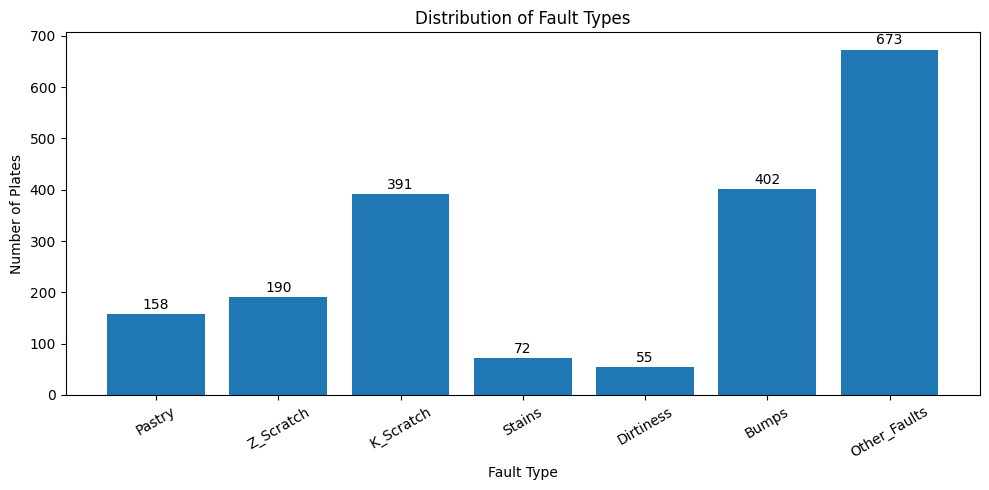

In [16]:
# Fault types and their counts
faults = ["Pastry", "Z_Scratch", "K_Scratch", "Stains",
          "Dirtiness", "Bumps", "Other_Faults"]

counts = [158, 190, 391, 72, 55, 402, 673]

# Create the bar chart
plt.figure(figsize=(10, 5))
plt.bar(faults, counts)

# Add labels
plt.xlabel("Fault Type")
plt.ylabel("Number of Plates")
plt.title("Distribution of Fault Types")

# Show the values on top of bars
for i, value in enumerate(counts):
    plt.text(i, value + 10, str(value), ha="center")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3 models
Logistic Regression
Random Forest
XGBoost

In [17]:
def make_classic_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                                random_state=42),
        "XGBoost": XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.08,
                                 random_state=42, verbosity=0),
    }
print("Models:", list(make_classic_models()))

Models: ['Logistic Regression', 'Random Forest', 'XGBoost']


##Test everything with 5-fold cross-validation

In [20]:
# Create 5 folds for cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get the names of the three models
model_names = list(make_classic_models())

# Store accuracy and F1 scores
results = {name: {"acc": [], "f1": []} for name in model_names}

# Store predictions
oof_pred = {name: np.zeros(len(y), dtype=int) for name in model_names}   # out-of-fold

# Run the models on each fold
for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y), start=1):

# Scale the data
    scaler = StandardScaler().fit(X[train_idx])            # fit on THIS fold only
    X_train = scaler.transform(X[train_idx]).astype("float32")
    X_val   = scaler.transform(X[val_idx]).astype("float32")

# collect predictions from every model
    predictions = {}
    for name, model in make_classic_models().items():
        model.fit(X_train, y[train_idx])
        predictions[name] = model.predict(X_val)
# Calculate the scores
    line = f"fold {fold}: "
    for name, pred in predictions.items():
        results[name]["acc"].append(accuracy_score(y[val_idx], pred))
        results[name]["f1"].append(f1_score(y[val_idx], pred, average="macro"))
        oof_pred[name][val_idx] = pred
        line += f"{name.split()[0]}={results[name]['f1'][-1]:.3f}  "
    print(line)

fold 1: Logistic=0.670  Random=0.819  XGBoost=0.829  
fold 2: Logistic=0.673  Random=0.797  XGBoost=0.808  
fold 3: Logistic=0.661  Random=0.797  XGBoost=0.837  
fold 4: Logistic=0.638  Random=0.810  XGBoost=0.844  
fold 5: Logistic=0.672  Random=0.794  XGBoost=0.837  


##Results

In [21]:
table = pd.DataFrame([
    {"Model": name,
     "Accuracy": f"{np.mean(r['acc']):.3f} ± {np.std(r['acc']):.3f}",
     "Macro F1": f"{np.mean(r['f1']):.3f} ± {np.std(r['f1']):.3f}",
     "_sort": np.mean(r["f1"])}
    for name, r in results.items()
])
table = table.sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)
print(table.to_string(index=False))

              Model      Accuracy      Macro F1
            XGBoost 0.811 ± 0.012 0.831 ± 0.013
      Random Forest 0.783 ± 0.005 0.803 ± 0.010
Logistic Regression 0.664 ± 0.015 0.663 ± 0.013


##confusion matrix + per-class report


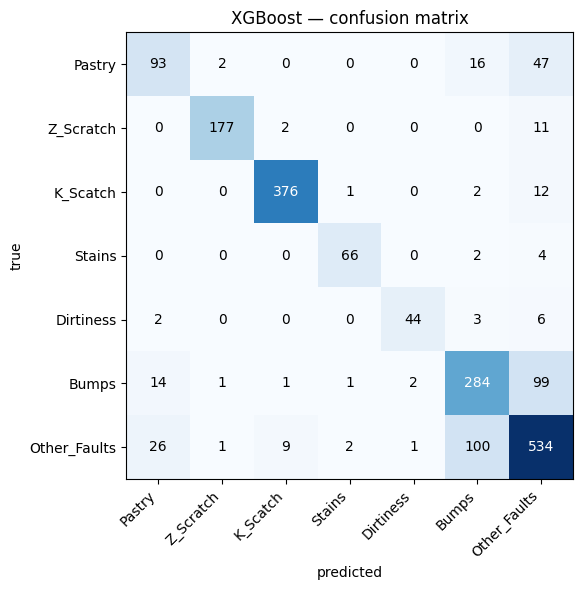

              precision    recall  f1-score   support

      Pastry      0.689     0.589     0.635       158
   Z_Scratch      0.978     0.932     0.954       190
    K_Scatch      0.969     0.962     0.965       391
      Stains      0.943     0.917     0.930        72
   Dirtiness      0.936     0.800     0.863        55
       Bumps      0.698     0.706     0.702       402
Other_Faults      0.749     0.793     0.771       673

    accuracy                          0.811      1941
   macro avg      0.852     0.814     0.831      1941
weighted avg      0.813     0.811     0.811      1941



In [22]:
best_model = table["Model"].iloc[0]
cm = confusion_matrix(y, oof_pred[best_model])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_classes)); ax.set_xticklabels(label_cols, rotation=45, ha="right")
ax.set_yticks(range(n_classes)); ax.set_yticklabels(label_cols)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{best_model} — confusion matrix")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

print(classification_report(y, oof_pred[best_model], target_names=label_cols, digits=3))